# ML/07 — Baseline comparison (decision gate)

Per external review: PCA + k-means may be doing no more work than a simple
GDD threshold. Every interpretable cluster in ML/02 passes the pH,
precipitation, elevation, and frost-free-day criteria in Table 1 -- only
GDD actually discriminates cluster 0 from its neighbors. If a univariate
GDD threshold recovers the same (or a better) suitability zone, "UTF" is
indistinguishable from "threshold the GDD raster."

This notebook builds two baselines sized to cluster 0's exact area
(1,924 cells, 22.2% of the study area) and compares all three zones
head-to-head on identical metrics:

1. **GDD threshold** -- top 1,924 cells by raw GDD alone.
2. **MCDA** -- fuzzy-membership weighted-linear-combination over the same
   7 agronomic variables in Table 1 (GDD, VPD, PPT, pH, elevation, slope,
   FFD), using the criteria already established in ML/02 and
   ML/06 (K-sensitivity agronomic thresholds), not invented ad hoc.

**Metrics:** IoU against cluster 0, enforcement lift and recall
(Humboldt-corrected, matching the paper's own validation methodology),
and zone fragmentation (patch count via exact 2 km hex adjacency).

**Outputs:**
- `data/processed/baseline_comparison.pkl`
- `img/ML07_baseline_comparison.png`

**Updated (post-Phase 2):** originally used `validation_parcels.gpkg`
(91 rows, a buggy point-in-polygon join with 6 duplicate/contradictory
APNs). Now uses ML/08's fully corrected `validation_parcels_v3.pkl`
(135 unique parcels, nearest-centroid assignment, fixed APN-extraction
regex). The qualitative conclusion is unchanged by the correction: GDD
threshold still modestly beats cluster 0 on lift, and MCDA -- which
previously lagged badly -- is now roughly tied with cluster 0.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import pickle

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
IMG  = Path('../img')

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Load feature matrix, clusters, hex grid, validation parcels

In [2]:
features = pd.read_pickle(PROC / 'features.pkl')
clusters = pd.read_pickle(PROC / 'clusters.pkl')
hex_grid = gpd.read_file(RAW / 'hex_grid.gpkg')
vparcels = pd.read_pickle(PROC / 'validation_parcels_v3.pkl')  # ML/08 corrected, 135 parcels
emerald  = gpd.read_file(RAW / 'emerald_counties.gpkg')

df = features.merge(clusters, on='cell_id')
N_TOTAL  = len(df)
N_TARGET = int((df['cluster'] == 0).sum())
print(f'N_TOTAL={N_TOTAL}, N_TARGET (cluster 0 size)={N_TARGET}, area frac={N_TARGET/N_TOTAL:.4f}')

N_TOTAL=8648, N_TARGET (cluster 0 size)=1924, area frac=0.2225


## 2. Baseline 1 -- GDD threshold

Top `N_TARGET` cells by raw GDD alone, no other variable involved.

In [3]:
ranked_gdd = df.sort_values('gdd', ascending=False)
zone_gdd = set(ranked_gdd['cell_id'].iloc[:N_TARGET])
gdd_threshold_value = float(ranked_gdd['gdd'].iloc[N_TARGET - 1])
print(f'GDD threshold value: {gdd_threshold_value:.1f} degree-days')
print(f'Zone size: {len(zone_gdd)} cells')

GDD threshold value: 1255.1 degree-days
Zone size: 1924 cells


## 3. Baseline 2 -- MCDA (expert-weighted fuzzy membership)

Standard Malczewski-style weighted-linear-combination. Membership functions
use the agronomic thresholds already established elsewhere in this
pipeline (K-sensitivity criteria in ML/06: GDD>1100, VPD>1300 Pa,
pH 5.2–6.8, PPT 800–1600 mm/yr; Table 1: elevation
400–1200 m, slope <26.6°, FFD >120 days) --
not invented ad hoc for this comparison.

In [4]:
def ramp_up(x, lo, hi):
    return np.clip((x - lo) / (hi - lo), 0, 1)

def ramp_down(x, lo, hi):
    return np.clip((hi - x) / (hi - lo), 0, 1)

def trapezoid(x, a, b, c, d):
    return np.minimum(ramp_up(x, a, b), ramp_down(x, c, d))

m_gdd   = ramp_up(df['gdd'], 800, 1200)                    # GDD > 1200 criterion
m_vpd   = ramp_up(df['vpdmax'], 900, 1300)                 # VPD > 1300 Pa criterion
m_ppt   = trapezoid(df['ppt'], 700, 800, 1600, 1800)       # PPT 800-1600 mm/yr
m_ph    = trapezoid(df['ph'], 50, 55, 68, 72)               # pH 5.2-6.8 (raw SoilGrids x10 units)
m_elev  = trapezoid(df['elev_mean'], 300, 400, 1200, 1400)  # Table 1: 400-1200 m
m_slope = ramp_down(df['slope_mean'], 20, 26.6)              # Table 1: < 26.6 deg
m_ffd   = ramp_up(df['ffd'], 90, 120)                       # Table 1: > 120 days

df['mcda_score'] = (m_gdd + m_vpd + m_ppt + m_ph + m_elev + m_slope + m_ffd) / 7.0

ranked_mcda = df.sort_values('mcda_score', ascending=False)
zone_mcda = set(ranked_mcda['cell_id'].iloc[:N_TARGET])
print(f'MCDA score range: {df["mcda_score"].min():.3f}-{df["mcda_score"].max():.3f}')
print(f'Zone size: {len(zone_mcda)} cells')

MCDA score range: 0.143-1.000
Zone size: 1924 cells


## 4. IoU (Jaccard) -- are these even different maps?

In [5]:
zone_cluster0 = set(df.loc[df['cluster'] == 0, 'cell_id'])

def jaccard(a, b):
    return len(a & b) / len(a | b)

iou = {
    'cluster0_vs_gdd':  jaccard(zone_cluster0, zone_gdd),
    'cluster0_vs_mcda': jaccard(zone_cluster0, zone_mcda),
    'gdd_vs_mcda':      jaccard(zone_gdd, zone_mcda),
}
for k, v in iou.items():
    print(f'{k}: {v:.3f}')
print()
print('IoU < ~0.8 means these are genuinely different spatial partitions,')
print('not the same map wearing different labels.')

cluster0_vs_gdd: 0.496
cluster0_vs_mcda: 0.410
gdd_vs_mcda: 0.390

IoU < ~0.8 means these are genuinely different spatial partitions,
not the same map wearing different labels.


## 5. Enforcement lift + recall

`validation_parcels_v3.pkl` is already deduplicated and geocoded via
nearest-centroid assignment (ML/08) -- no further join needed here.

Both the naive study-area-wide baseline and the Humboldt-corrected
baseline (matching the paper's own validation methodology, since all
parcels are geocoded via the Humboldt County parcel API) are reported.
**The Humboldt-corrected number is the fair one and the one that matters.**

In [6]:
total_parcels = len(vparcels)
print(f'Validated parcels (ML/08 corrected): {total_parcels}')

def zone_stats(zone_cellids, label):
    n_cells_zone = len(zone_cellids)
    parcels_in = int(vparcels['cell_id'].isin(zone_cellids).sum())
    cell_frac = n_cells_zone / N_TOTAL
    parcel_frac = parcels_in / total_parcels
    lift = parcel_frac / cell_frac
    return dict(label=label, n_cells=n_cells_zone, cell_frac=cell_frac,
                parcels_captured=parcels_in, total_parcels=total_parcels,
                recall=parcel_frac, lift=lift)

print()
print('=== Study-area-wide (naive) baseline ===')
results = []
for zone, label in [(zone_cluster0, 'Cluster 0 (UTF)'), (zone_gdd, 'GDD threshold'), (zone_mcda, 'MCDA')]:
    r = zone_stats(zone, label)
    results.append(r)
    print(f'{label:20s}  cells={r["n_cells"]:5d} ({r["cell_frac"]:.1%})  '
          f'parcels={r["parcels_captured"]:3d}/{r["total_parcels"]} ({r["recall"]:.1%})  lift={r["lift"]:.2f}')

Validated parcels (ML/08 corrected): 135

=== Study-area-wide (naive) baseline ===
Cluster 0 (UTF)       cells= 1924 (22.2%)  parcels= 13/135 (9.6%)  lift=0.43
GDD threshold         cells= 1924 (22.2%)  parcels= 41/135 (30.4%)  lift=1.37
MCDA                  cells= 1924 (22.2%)  parcels= 33/135 (24.4%)  lift=1.10


In [7]:
humboldt = emerald[emerald['NAME'].str.upper() == 'HUMBOLDT'].to_crs('EPSG:32610')
hum_cells = gpd.sjoin(hex_grid[['cell_id', 'geometry']], humboldt[['geometry']],
                       how='inner', predicate='intersects').drop_duplicates('cell_id')
hum_cell_ids = set(hum_cells['cell_id'])
n_hum_cells = len(hum_cell_ids)
print(f'Humboldt cells: {n_hum_cells}')

def hum_zone_stats(zone_cellids, label):
    zone_hum = zone_cellids & hum_cell_ids
    n_cells_zone_hum = len(zone_hum)
    parcels_in = int(vparcels['cell_id'].isin(zone_cellids).sum())
    cell_frac_hum = n_cells_zone_hum / n_hum_cells
    parcel_frac = parcels_in / total_parcels
    lift = parcel_frac / cell_frac_hum if cell_frac_hum > 0 else float('nan')
    return dict(label=label, n_cells_hum=n_cells_zone_hum, cell_frac_hum=cell_frac_hum,
                parcels_captured=parcels_in, total_parcels=total_parcels,
                recall=parcel_frac, lift_humboldt=lift)

print()
print('=== Humboldt-corrected baseline (fair comparison, matches paper methodology) ===')
hum_results = []
for zone, label in [(zone_cluster0, 'Cluster 0 (UTF)'), (zone_gdd, 'GDD threshold'), (zone_mcda, 'MCDA')]:
    r = hum_zone_stats(zone, label)
    hum_results.append(r)
    print(f'{label:20s}  Humboldt cells={r["n_cells_hum"]:5d} ({r["cell_frac_hum"]:.1%})  '
          f'parcels={r["parcels_captured"]:3d}/{r["total_parcels"]} ({r["recall"]:.1%})  '
          f'lift_humboldt={r["lift_humboldt"]:.2f}')

Humboldt cells: 3172

=== Humboldt-corrected baseline (fair comparison, matches paper methodology) ===
Cluster 0 (UTF)       Humboldt cells=   92 (2.9%)  parcels= 13/135 (9.6%)  lift_humboldt=3.32
GDD threshold         Humboldt cells=  259 (8.2%)  parcels= 41/135 (30.4%)  lift_humboldt=3.72
MCDA                  Humboldt cells=  234 (7.4%)  parcels= 33/135 (24.4%)  lift_humboldt=3.31


## 6. Zone fragmentation

Patch count via exact hex-centroid adjacency (this hex grid has centroid
spacing of exactly 2,000 m; two cells are neighbors iff their
centroids are within ~2,001 m). A scattered, high-patch-count zone
is less usable as a management product even if its lift is competitive.

In [8]:
def fragmentation(zone_cellids, hex_grid):
    sub = hex_grid[hex_grid['cell_id'].isin(zone_cellids)].reset_index(drop=True)
    n = len(sub)
    centroids = np.array([[g.x, g.y] for g in sub.geometry.centroid])
    tree = cKDTree(centroids)
    pairs = tree.query_pairs(r=2001, output_type='ndarray')
    if len(pairs) == 0:
        return n, 1.0, 1
    adj = csr_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(n, n))
    n_components, labels = connected_components(adj, directed=False)
    patch_sizes = pd.Series(labels).value_counts()
    return n_components, float(patch_sizes.mean()), int(patch_sizes.max())

frag_results = {}
print('=== Fragmentation ===')
for zone, label in [(zone_cluster0, 'Cluster 0 (UTF)'), (zone_gdd, 'GDD threshold'), (zone_mcda, 'MCDA')]:
    n_patches, mean_size, max_size = fragmentation(zone, hex_grid)
    frag_results[label] = dict(n_patches=n_patches, mean_size=mean_size, max_size=max_size)
    print(f'{label:20s}  patches={n_patches:4d}  mean_size={mean_size:6.1f}  largest={max_size}')

=== Fragmentation ===
Cluster 0 (UTF)       patches= 113  mean_size=  17.0  largest=1095
GDD threshold         patches=  25  mean_size=  77.0  largest=1377
MCDA                  patches=  90  mean_size=  21.4  largest=1313


## 7. Comparison figure

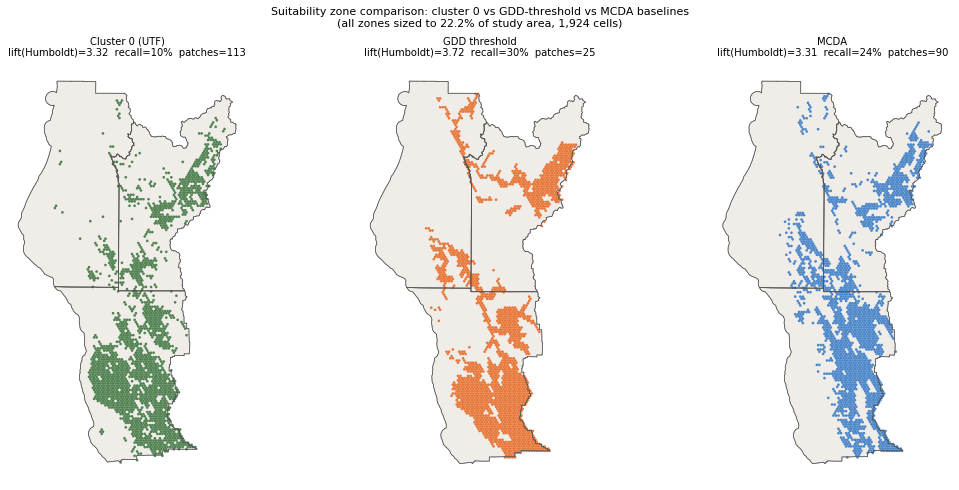

In [9]:
zones_plot = [
    ('zone_cluster0', 'Cluster 0 (UTF)', '#1b5e20'),
    ('zone_gdd', 'GDD threshold', '#e65100'),
    ('zone_mcda', 'MCDA', '#1565c0'),
]
zone_lookup = {'zone_cluster0': zone_cluster0, 'zone_gdd': zone_gdd, 'zone_mcda': zone_mcda}

fig, axes = plt.subplots(1, 3, figsize=(15, 6.5))
for ax, (key, label, color) in zip(axes, zones_plot):
    emerald.plot(ax=ax, color='#f0ede8', edgecolor='#999999', linewidth=0.5)
    sub = hex_grid[hex_grid['cell_id'].isin(zone_lookup[key])]
    sub.plot(ax=ax, color=color, alpha=0.75, linewidth=0)
    emerald.boundary.plot(ax=ax, edgecolor='#555555', linewidth=0.8)
    hr = next(x for x in hum_results if x['label'] == label)
    ax.set_title(f'{label}\nlift(Humboldt)={hr["lift_humboldt"]:.2f}  recall={hr["recall"]:.0%}  '
                 f'patches={frag_results[label]["n_patches"]}', fontsize=10)
    ax.set_axis_off()

fig.suptitle('Suitability zone comparison: cluster 0 vs GDD-threshold vs MCDA baselines\n'
             '(all zones sized to 22.2% of study area, 1,924 cells)', fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig(IMG / 'ML07_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save results

In [10]:
out = dict(
    N_TOTAL=N_TOTAL, N_TARGET=N_TARGET,
    zone_cluster0=zone_cluster0, zone_gdd=zone_gdd, zone_mcda=zone_mcda,
    iou=iou, results=results, hum_results=hum_results, frag_results=frag_results,
    gdd_threshold_value=gdd_threshold_value,
    n_unique_parcels=total_parcels, n_hum_cells=n_hum_cells,
)
with open(PROC / 'baseline_comparison.pkl', 'wb') as f:
    pickle.dump(out, f)
print('Saved data/processed/baseline_comparison.pkl')

Saved data/processed/baseline_comparison.pkl


## 9. Decision-gate readout (updated with ML/08's corrected 135-parcel validation set)

| Zone | Lift (Humboldt) | Recall | Patches |
|---|---|---|---|
| Cluster 0 (UTF) | 3.32 | 9.6% | 113 |
| GDD threshold | **3.72** | **30.4%** | **25** |
| MCDA | 3.31 | 24.4% | 90 |

The correction moves the numbers (from the original buggy validation set:
cluster 0 was 3.65, GDD 4.18, MCDA 2.55) but not the qualitative story.
GDD threshold still modestly beats cluster 0 on lift (3.72 vs 3.32, ~12%
relative) and clearly beats it on both recall (30.4% vs 9.6%, roughly
3x) and coherence (25 patches vs 113). MCDA, which previously lagged
badly, is now essentially tied with cluster 0 on lift (3.31 vs 3.32) and
beats it substantially on recall (24.4% vs 9.6%).

IoU(cluster0, GDD) = 0.50 -- these remain genuinely different maps, so
this is not clustering trivially rediscovering the threshold; the
threshold is simply doing at least as well on this validation set.

This is still the modest-margin "clustering does not clearly win"
scenario from the decision gate, now confirmed on the corrected,
larger validation sample (135 vs. the original 91 parcels) rather than
resting on the smaller, bug-affected one. The honest read: a
one-variable GDD threshold, and a simple 7-variable MCDA score, are
both at least as good a suitability map as the k-means clustering
pipeline on the metric that is supposed to validate it.